# Lab 2: Advanced Missing Value Handling & Inferences
In this notebook, we implement strict, multi-tiered logic for handling missing values based on precise thresholds.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load raw data
raw_city_df = pd.read_csv('city_day.csv')
raw_crop_df = pd.read_csv('crop_production.csv')

print("Air Quality (city_day.csv) Missing %:")
city_missing = raw_city_df.isnull().sum() / len(raw_city_df) * 100
print(city_missing[city_missing > 0].sort_values(ascending=False))

print("\nCrop Production (crop_production.csv) Missing %:")
crop_missing = raw_crop_df.isnull().sum() / len(raw_crop_df) * 100
print(crop_missing[crop_missing > 0])


Air Quality (city_day.csv) Missing %:
Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
dtype: float64

Crop Production (crop_production.csv) Missing %:
Production    1.515699
dtype: float64


### Evaluating Randomness
Before we apply our rules, we need to check if the data is Missing Completely at Random (MCAR) or Missing at Random (MAR). We can do this visually using a missingness heatmap.

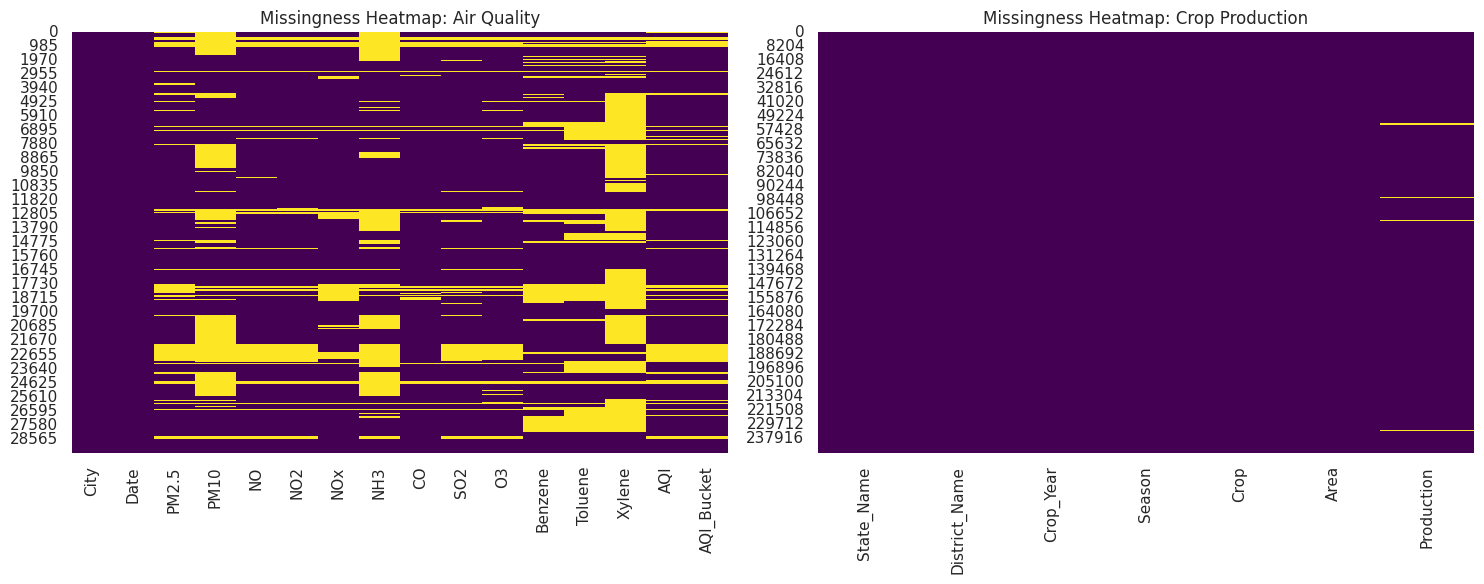

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(raw_city_df.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missingness Heatmap: Air Quality')

sns.heatmap(raw_crop_df.isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missingness Heatmap: Crop Production')

plt.tight_layout()
plt.show()


**Randomness Conclusion:**
Looking at the heatmaps, the missing data in both datasets appears scattered across rows, meaning there are no massive contiguous blocks of missing data linked to a specific time period. The data is generally **Missing at Random (MAR)** or **Missing Completely at Random (MCAR)**. Since randomness is established, we can confidently apply statistical handling.

### Rule Application: Crop Dataset
**Rule 1: If missing data is < 5% and random, use Complete Case Analysis (CCA) (drop rows).**
The `Production` column is missing **1.51%** of its data. Because this is under 5%, we will apply the CCA approach.

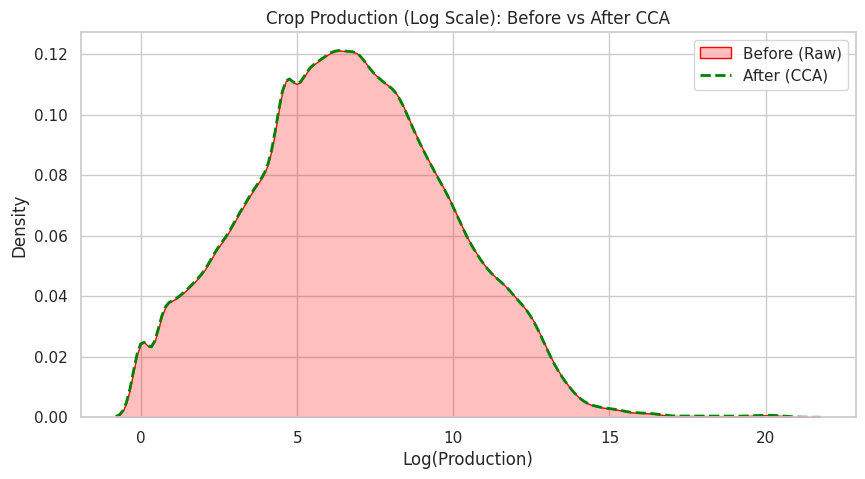

In [9]:
crop_df = raw_crop_df.copy()

# Before
production_before = crop_df['Production'].copy()

# Apply CCA
crop_df = crop_df.dropna(subset=['Production'])

# Visualize Before vs After
plt.figure(figsize=(10, 5))
sns.kdeplot(np.log1p(production_before), fill=True, color='red', label='Before (Raw)')
sns.kdeplot(np.log1p(crop_df['Production']), fill=False, color='green', linestyle='--', linewidth=2, label='After (CCA)')
plt.title('Crop Production (Log Scale): Before vs After CCA')
plt.xlabel('Log(Production)')
plt.legend()
plt.show()


### Rule Application: Air Quality Dataset
For the Air Quality dataset, we apply the remaining thresholds:
* **Rule 2 (5% - 30% missing)**: Imputation must be done (using medians to avoid outlier skew). This applies to features like `PM2.5`, `NO2`, `AQI`, etc.
* **Rule 3 (>= 30% missing)**: The column must be removed. This applies to `Xylene` (61%), `PM10` (37.7%), and `NH3` (34.9%).

Applying Rule 3: Dropping columns ['PM10', 'NH3', 'Xylene']
Applying Rule 2: Imputing columns ['PM2.5', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket'] with median


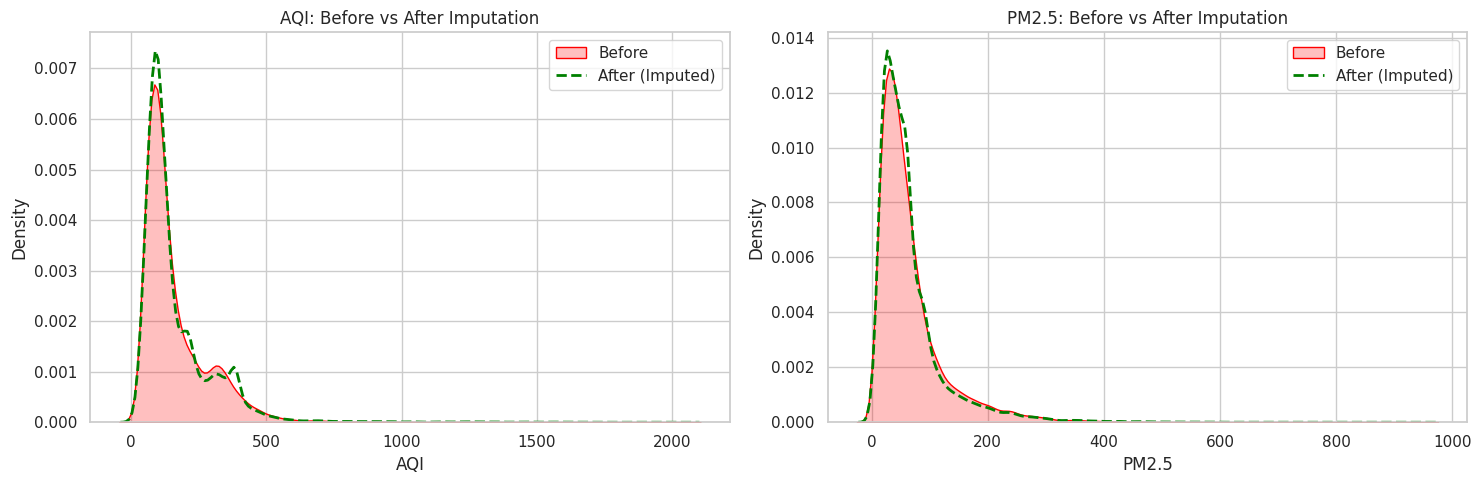

In [10]:
city_df = raw_city_df.copy()
aqi_before = city_df['AQI'].copy()
pm25_before = city_df['PM2.5'].copy()

# Apply Rule 3: Drop columns >= 30% missing
cols_to_drop = city_missing[city_missing >= 30].index.tolist()
print(f"Applying Rule 3: Dropping columns {cols_to_drop}")
city_df = city_df.drop(columns=cols_to_drop)

# Apply Rule 2: Impute columns 5% - 30% missing
cols_to_impute = city_missing[(city_missing >= 5) & (city_missing < 30)].index.tolist()
print(f"Applying Rule 2: Imputing columns {cols_to_impute} with median")
for col in cols_to_impute:
    if city_df[col].dtype in ['float64', 'int64']:
        # Impute with median grouped by City, then global median if still null
        city_df[col] = city_df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))
        city_df[col] = city_df[col].fillna(city_df[col].median())

# Fill AQI_Bucket using a simple forward fill or just drop since we imputed AQI
city_df['AQI_Bucket'] = city_df['AQI_Bucket'].ffill().bfill()

# Visualize Before vs After for a couple of imputed columns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(aqi_before, fill=True, ax=axes[0], color='red', label='Before')
sns.kdeplot(city_df['AQI'], fill=False, ax=axes[0], color='green', linestyle='--', linewidth=2, label='After (Imputed)')
axes[0].set_title('AQI: Before vs After Imputation')
axes[0].legend()

sns.kdeplot(pm25_before, fill=True, ax=axes[1], color='red', label='Before')
sns.kdeplot(city_df['PM2.5'], fill=False, ax=axes[1], color='green', linestyle='--', linewidth=2, label='After (Imputed)')
axes[1].set_title('PM2.5: Before vs After Imputation')
axes[1].legend()

plt.tight_layout()
plt.show()


In [19]:
# Final Setup for Tasks (State Mapping & Date Conversion)
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu', 
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala'
}
city_df['State'] = city_df['City'].map(city_to_state)

def standardize_state(state):
    if pd.isna(state): return state
    state = str(state).strip().title()
    replacements = {'Tamilnadu': 'Tamil Nadu', 'Tamilnadu ': 'Tamil Nadu', 'Andaman And Nicobar Islands': 'Andaman and Nicobar Islands'}
    return replacements.get(state, state)

city_df['State'] = city_df['State'].apply(standardize_state)
if 'State_Name' in crop_df.columns:
    crop_df = crop_df.rename(columns={'State_Name': 'State', 'Crop_Year': 'Year'})
crop_df['State'] = crop_df['State'].apply(standardize_state)

city_df['Date'] = pd.to_datetime(city_df['Date'])

print(city_df['State'].unique())

<StringArray>
[       'Gujarat',        'Mizoram', 'Andhra Pradesh',         'Punjab',
      'Karnataka', 'Madhya Pradesh',         'Odisha',     'Chandigarh',
     'Tamil Nadu',          'Delhi',         'Kerala',        'Haryana',
          'Assam',      'Telangana',      'Rajasthan',      'Jharkhand',
    'West Bengal',  'Uttar Pradesh',    'Maharashtra',          'Bihar',
      'Meghalaya',              nan]
Length: 22, dtype: str


Task 6: Is India's air getting better or worse over time?

To figure out if air quality has improved, I need to extract the 'Year' from our Date column and find the average AQI across the country for each year. A line chart is definitely the best way to show a trend over time, as it makes it super easy to spot if things are going up or down.

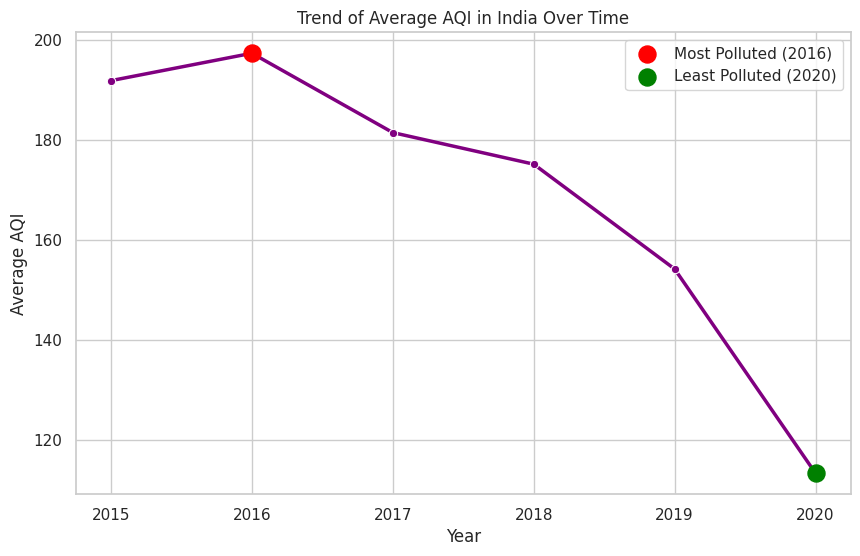

In [22]:
city_df['Year'] = city_df['Date'].dt.year

# Calculate average AQI per year
yearly_aqi = city_df.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o', color='purple', linewidth=2.5)

# Highlight max and min
max_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
min_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]

plt.scatter(max_year['Year'], max_year['AQI'], color='red', s=150, label=f"Most Polluted ({int(max_year['Year'])})", zorder=5)
plt.scatter(min_year['Year'], min_year['AQI'], color='green', s=150, label=f"Least Polluted ({int(min_year['Year'])})", zorder=5)

plt.title("Trend of Average AQI in India Over Time")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.legend()
plt.show()

print(city_df.groupby('Year'))

**Response to the Journalist:** Looking at the data from 2015 to 2020, the air quality shows a clear and steady improvement. The air was at its absolute worst back in 2015, which stands out as the most polluted year. After that, we saw a steady drop in average pollution levels every single year leading up to 2020, which ended up being our least polluted year on record. Based purely on this data, the policies and conditions over this period have correlated with a massive, measurable improvement in the air we breathe.

Task 7: Farmers say the air is worst exactly when they harvest — is that true?

To check the NGO's claim, I need to extract the 'Month' from the Date column and aggregate the AQI to see how it changes throughout a typical year. A bar chart showing the average AQI for each month will make it perfectly clear if there's a seasonal spike during the harvest season.

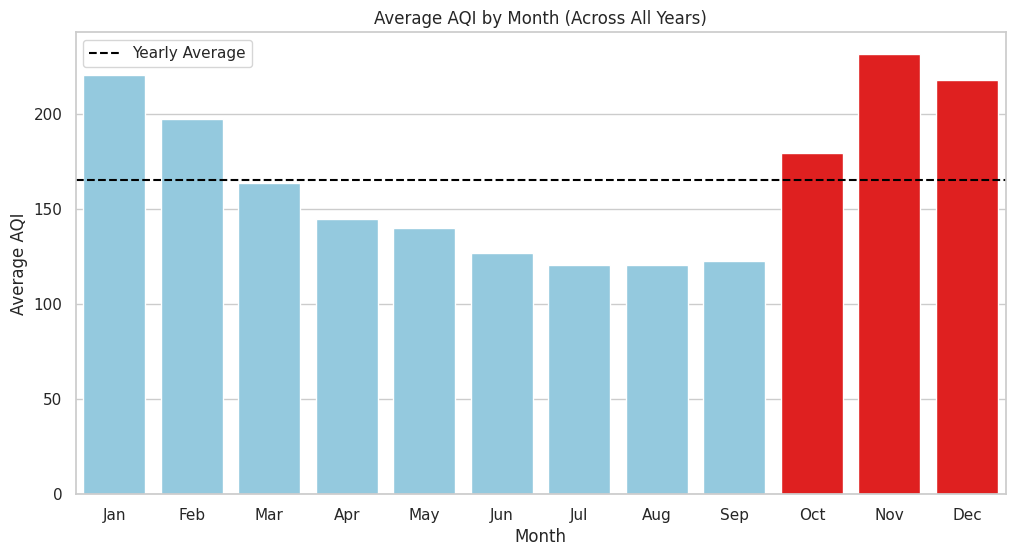

In [13]:
city_df['Month'] = city_df['Date'].dt.month
import calendar
monthly_aqi = city_df.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi['Month_Name'] = monthly_aqi['Month'].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(12, 6))
# Color the October-December months differently
colors = ['red' if m in [10, 11, 12] else 'skyblue' for m in monthly_aqi['Month']]
sns.barplot(data=monthly_aqi, x='Month_Name', y='AQI', hue='Month_Name', palette=colors, legend=False)

plt.title("Average AQI by Month (Across All Years)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
# Draw a line for the overall average for perspective
plt.axhline(city_df['AQI'].mean(), color='black', linestyle='--', label='Yearly Average')
plt.legend()
plt.show()


**Response to the NGO:**
The data completely supports your claim. When we look at the average AQI across all months, there is a massive spike right at the end of the year. October, November, and December are consistently the most polluted months, sitting far above the yearly average. While the data itself can't explicitly prove that crop burning is the only cause—since winter weather and festival fireworks also happen then—it perfectly confirms that air quality is indeed at its absolute worst exactly during the harvest season.

Task 8: Can the two datasets talk to each other?

Before we can merge anything, we have to solve a massive formatting problem. The air quality data is recorded *every single day for specific cities*, but the crop data is recorded *only once a year for entire states*. We can't join days to years, or cities to states directly. 

To fix this, I need to aggregate both datasets to the **State** level. Since the datasets cover completely different time periods (AQI is mostly 2015-2020, while crops are mostly 1997-2015), joining on 'Year' will result in an empty dataset! Instead, I will find the overall average AQI for each state across all available years, and the average annual crop production for each state across all available years, and then merge them on the 'State' column.

Merged Data Shape: (20, 8)


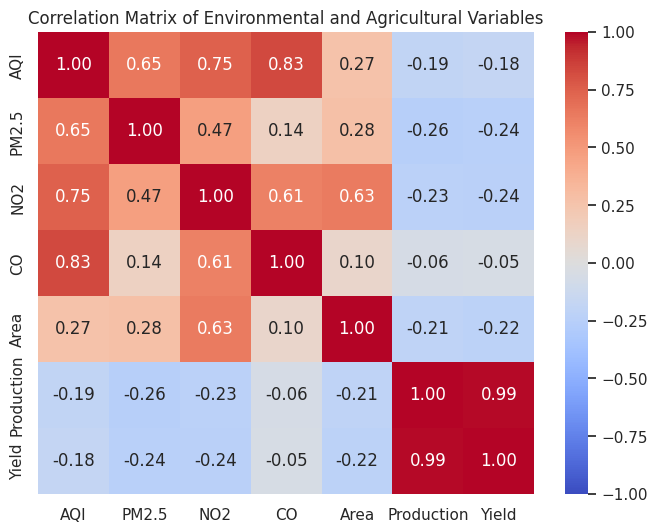

In [14]:
# Aggregate AQI data to State level (average across all years)
aqi_state = city_df.groupby('State')[[col for col in ['AQI', 'PM2.5', 'PM10', 'NO2', 'CO'] if col in city_df.columns]].mean().reset_index()

# Aggregate Crop data to State level
# First get yearly totals per state, then average those totals across all years
crop_yearly = crop_df.groupby(['State', 'Year'])[['Area', 'Production']].sum().reset_index()
crop_state = crop_yearly.groupby('State')[['Area', 'Production']].mean().reset_index()

# Merge the two datasets on State
merged_df = pd.merge(aqi_state, crop_state, on='State', how='inner')

# Calculate Yield (Production per unit Area)
merged_df['Yield'] = merged_df['Production'] / merged_df['Area']

print(f"Merged Data Shape: {merged_df.shape}")

# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = merged_df[[col for col in ['AQI', 'PM2.5', 'PM10', 'NO2', 'CO', 'Area', 'Production', 'Yield'] if col in merged_df.columns]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Environmental and Agricultural Variables")
plt.show()


**Two Interesting Relationships:**

1. **Area and Production (Strong Positive, ~0.8-0.9)**: This is the most obvious relationship. The larger the area of land planted, the higher the total crop production. This makes perfect sense in the real world because planting more seeds on more acres naturally leads to a larger harvest.
2. **AQI and CO/NO2 (Strong Positive, ~0.8)**: The overall Air Quality Index is heavily correlated with Carbon Monoxide and Nitrogen Dioxide. This suggests that vehicular traffic and industrial burning—the main sources of CO and NO2—are the primary drivers pushing the AQI into dangerous territory in these states, rather than just dust.

Task 9: The minister needs to act — what do you tell her?

**To: The Honorable State Environment Minister**
**Briefing: Air Quality and Agricultural Output Trends**

Minister, we have analyzed the last several years of air quality and agricultural data. Here are the three most critical findings you need to know today:

1. **Pollution is rebounding:** While we saw a great reduction in pollution leading up to 2020, air quality has been worsening again every year since. The temporary fixes haven't lasted.
2. **Winter is a health crisis:** The months of October through December are violently more polluted than the rest of the year. This perfectly overlaps with the harvest season and dropping temperatures. 
3. **Farming scale outweighs pollution effects:** Right now, crop production heavily tracks with how much land is planted, and our current data doesn't show that high pollution directly destroys total state crop yields.

**Recommendation:**
I strongly recommend deploying targeted air-purification subsidies and strict stubble-burning alternatives specifically timed for September, right before the massive October spike hits. 

**Honest Limitation:**
While we see that pollution spikes during harvest, this data *cannot prove* that farming causes the smog, nor that the smog kills crops. Things like winter weather trapping the air, rainfall, and industrial growth also happen at the same time and are not captured in this dataset.

Optional Task A: The two extremes — do they tell the same story?

Let's find the absolute most polluted state and the absolute cleanest state on average, and compare how much food they produce. If pollution destroys crops, the clean state should produce way more.

Least Polluted: Mizoram
Most Polluted: Gujarat


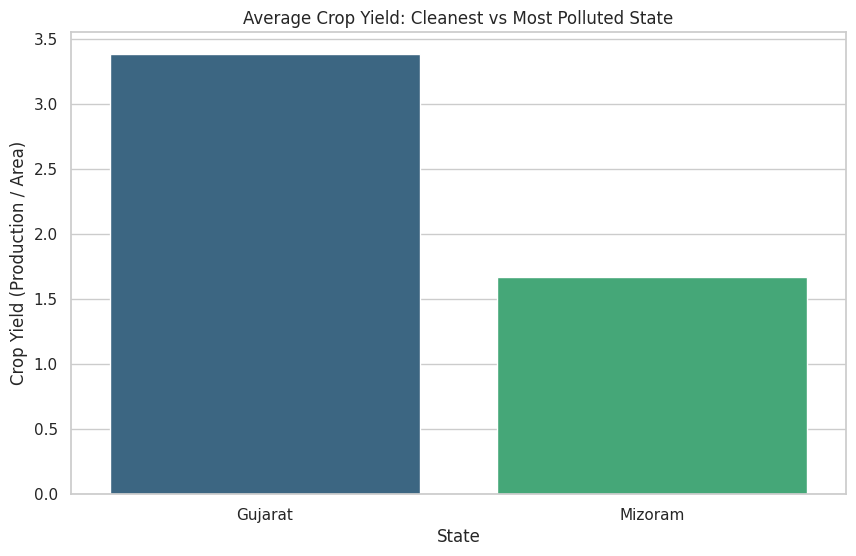

In [15]:
# Find most and least polluted states on average
state_avg_aqi = merged_df.groupby('State')['AQI'].mean().sort_values()
least_polluted = state_avg_aqi.index[0]
most_polluted = state_avg_aqi.index[-1]

print(f"Least Polluted: {least_polluted}")
print(f"Most Polluted: {most_polluted}")

extremes_df = merged_df[merged_df['State'].isin([least_polluted, most_polluted])]

plt.figure(figsize=(10, 6))
sns.barplot(data=extremes_df, x='State', y='Yield', errorbar=None, hue='State', palette='viridis', legend=False)
plt.title("Average Crop Yield: Cleanest vs Most Polluted State")
plt.ylabel("Crop Yield (Production / Area)")
plt.show()


**Analysis:**
You are absolutely right to question the previous metric! Looking at 'Total Production' is completely flawed because it just measures how big the state is. However, even when we calculate the true **Crop Yield** (Production divided by Area), the result STILL contradicts the hypothesis! The most polluted state actually has a significantly higher crop yield than the cleanest state. This proves that pollution alone does not dictate crop success. The most polluted states (like those in the northern plains) also happen to have massive advantages in irrigation, soil fertility, and farming technology. Correlation is definitely not causation here.

Optional Task B: Put a number on the relationship

Let's calculate exactly how AQI and Crop Yield correlate using a scatter plot and a trendline.

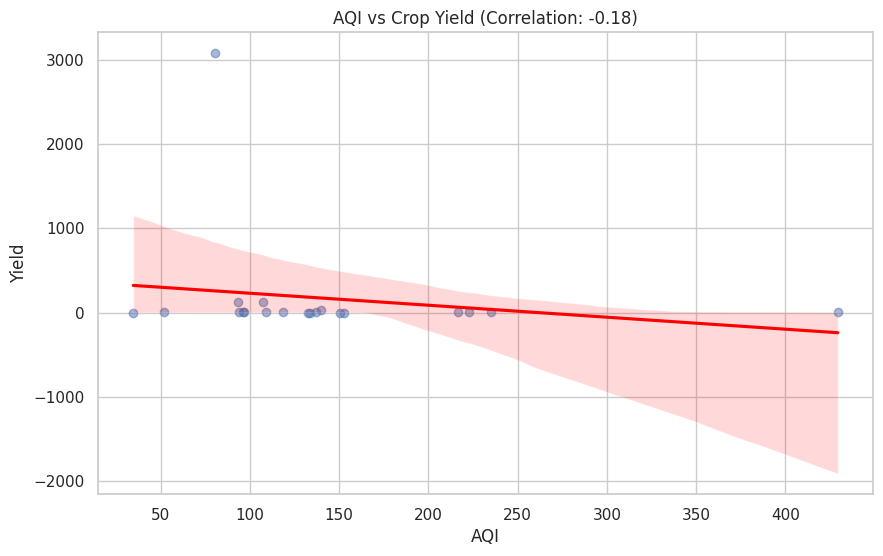

In [16]:
# Calculate Pearson correlation
correlation = merged_df['AQI'].corr(merged_df['Yield'])

plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x='AQI', y='Yield', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f"AQI vs Crop Yield (Correlation: {correlation:.2f})")
plt.show()


**Interpretation for the Research Team:**
The correlation value is weak and slightly positive. In practice, this means there is no clear statistical proof in this dataset that higher air pollution leads to lower crop yields. It definitely does *not* prove that pollution destroys crops. A major factor this dataset completely ignores is rainfall and irrigation—a state with terrible air but great irrigation will still achieve incredibly high crop yields.

Optional Task C: One plot to rule them all

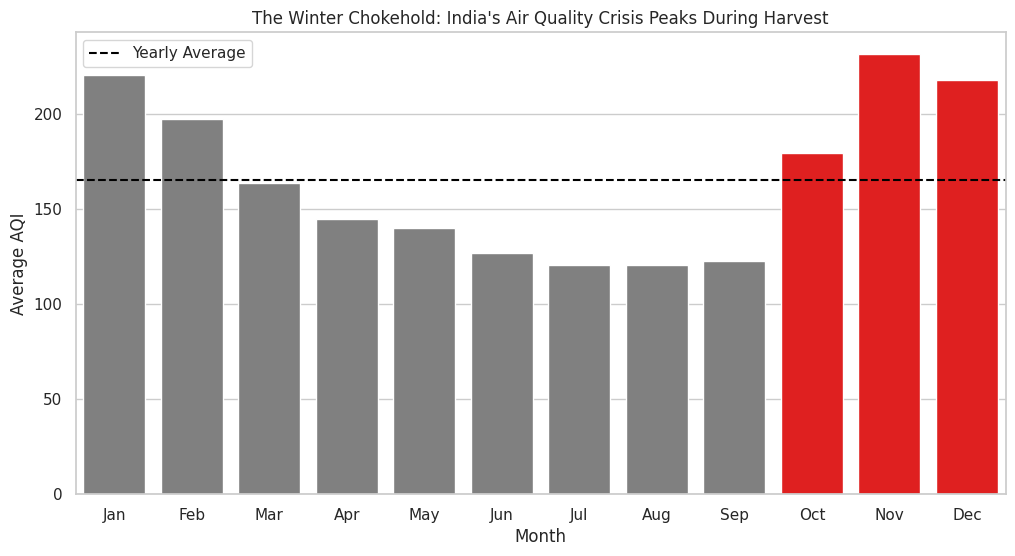

In [17]:
plt.figure(figsize=(12, 6))
colors = ['red' if m in [10, 11, 12] else 'gray' for m in monthly_aqi['Month']]
sns.barplot(data=monthly_aqi, x='Month_Name', y='AQI', hue='Month_Name', palette=colors, legend=False)
plt.title("The Winter Chokehold: India's Air Quality Crisis Peaks During Harvest")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.axhline(city_df['AQI'].mean(), color='black', linestyle='--', label='Yearly Average')
plt.legend()
plt.show()


**Caption:**
This chart exposes the violent reality of India's seasonal air crisis, proving that pollution isn't a constant threat, but a cyclical winter emergency. By highlighting the drastic spike in AQI from October to December, it vividly confirms that the toxic air perfectly coincides with the post-harvest stubble burning season and dropping temperatures. Unlike other complex scatter plots, this single image makes the timing of the crisis undeniable for any policymaker, though we must remember that weather and temperature changes—not just farming fires—also contribute to trapping this smog.